# Exploratory Data Analysis(EDA)

In [8]:
#importing libraries
import ast
import pandas as pd
import seaborn as sns
from datasets import load_dataset
import matplotlib.pyplot as plt
from adjustText import adjust_text


#loading data from Hugging face
dataset=load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()


#Data Cleanup
df['job_posted_date']= pd.to_datetime(df['job_posted_date'])
df['job_skills']= df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

## Filter for US Data Analyst Roles

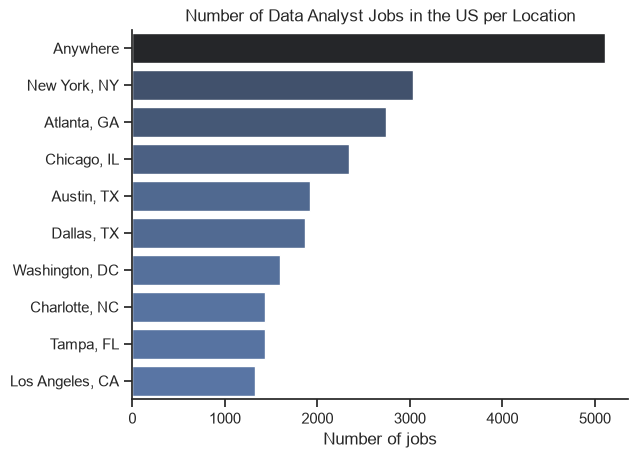

In [18]:
df_DA_US=df[(df['job_country']=='United States') & (df['job_title_short']=='Data Analyst')]
df_plot = df_DA_US['job_location'].value_counts().head(10).to_frame()
sns.set_theme(style='ticks')
sns.barplot(data=df_plot,x='count',y='job_location', hue='count',palette='dark:b_r',legend=False)
sns.despine()
plt.title('Number of Data Analyst Jobs in the US per Location')
plt.xlabel('Number of jobs')
plt.ylabel('')
plt.show()

## A look at Job work from home percentage , Jobs degree Required and If Health Insurance is offered

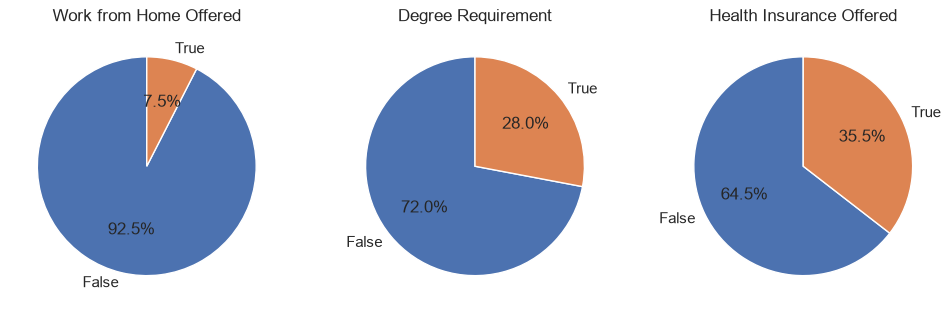

In [19]:
dict_column={'job_work_from_home':'Work from Home Offered' ,
             'job_no_degree_mention':'Degree Requirement',
             'job_health_insurance':'Health Insurance Offered'
             }

fig, ax = plt.subplots(1,3)
fig.set_size_inches((12,5))
              
for i,(column,title) in enumerate(dict_column.items()):
  ax[i].pie(df_DA_US[column].value_counts(),startangle=90,autopct='%1.1f%%', labels=['False','True'])
  ax[i].set_title(title) 

plt.show()

## Explores Top 10 companies for Data Analyst jobs in the US by job count

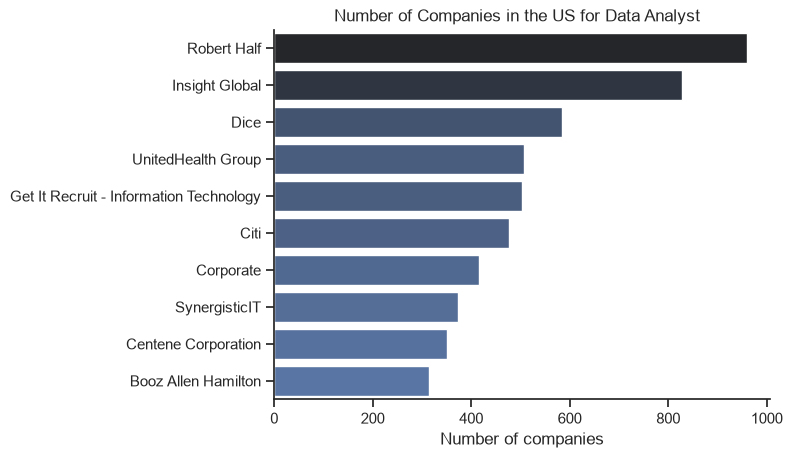

In [21]:
df_plot = df_DA_US['company_name'].value_counts().head(10).to_frame()
sns.set_theme(style='ticks')
sns.barplot(data=df_plot,x='count',y='company_name', hue='count',palette='dark:b_r',legend=False)
sns.despine()
plt.title('Number of Companies in the US for Data Analyst  ')
plt.xlabel('Number of companies')
plt.ylabel('')
plt.show()

## Top Trending skills for Data Analyst throughout the Year

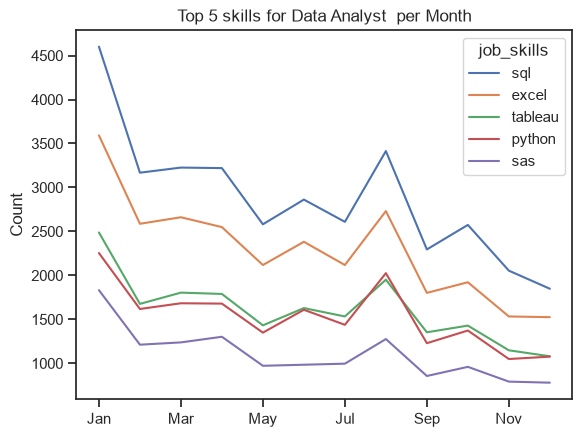

In [22]:
df_DA_US['job_posted_month_no'] = df_DA_US['job_posted_date'].dt.month
df_DA_US_explode = df_DA_US.explode('job_skills')
df_DA_US_pivot = df_DA_US_explode.pivot_table(index='job_posted_month_no',columns='job_skills', aggfunc='size', fill_value=0)
df_DA_US_pivot.loc['Total']= df_DA_US_pivot.sum()

df_DA_US_pivot = df_DA_US_pivot[df_DA_US_pivot.loc['Total'].sort_values(ascending=False).index]

df_DA_US_pivot = df_DA_US_pivot.drop('Total')

df_DA_US_pivot = df_DA_US_pivot.reset_index()
df_DA_US_pivot['job_posted_month']= df_DA_US_pivot['job_posted_month_no'].apply(lambda x: pd.to_datetime(x, format='%m').strftime( "%b"))
df_DA_US_pivot = df_DA_US_pivot.set_index('job_posted_month')
df_DA_US_pivot = df_DA_US_pivot.drop(columns='job_posted_month_no')

#get the top 5 skills 
df_DA_US_pivot.iloc[:, :5].plot(kind='line')

plt.title('Top 5 skills for Data Analyst  per Month')
plt.ylabel('Count')
plt.xlabel('')
plt.show()